In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv('dataset/data.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  10000 non-null  int64  
 1   Gender               10000 non-null  str    
 2   Symptoms_Text        10000 non-null  str    
 3   Sodium_mmol_L        10000 non-null  float64
 4   Potassium_mmol_L     10000 non-null  float64
 5   Chloride_mmol_L      10000 non-null  float64
 6   WBC_109_per_L        10000 non-null  float64
 7   Hemoglobin_g_dL      10000 non-null  float64
 8   Platelets_109_per_L  10000 non-null  int64  
 9   Urea_mg_dL           10000 non-null  int64  
 10  Creatinine_mg_dL     10000 non-null  float64
 11  Bilirubin_mg_dL      10000 non-null  float64
 12  ALT_U_L              10000 non-null  int64  
 13  AST_U_L              10000 non-null  int64  
 14  Water_Source         10000 non-null  str    
 15  Hygiene_Score        10000 non-null  int64  
 16

In [4]:
data.drop(columns=['Symptoms_Text'], inplace=True)
data.head()

,Age,Gender,Sodium_mmol_L,Potassium_mmol_L,Chloride_mmol_L,WBC_109_per_L,Hemoglobin_g_dL,Platelets_109_per_L,Urea_mg_dL,Creatinine_mg_dL,Bilirubin_mg_dL,ALT_U_L,AST_U_L,Water_Source,Hygiene_Score,Disease
0,82,Male,128.3,2.8,90.9,7.4,12.4,234,51,1.29,0.6,23,18,Tap,2,Cholera
1,55,Female,121.3,2.9,98.5,9.6,13.2,259,46,1.48,0.6,27,35,River,5,Cholera
2,25,Male,132.1,3.3,94.5,11.0,10.7,203,50,1.29,0.9,12,29,Well,2,Cholera
3,60,Female,123.2,2.8,93.2,7.6,10.8,291,56,1.02,0.9,22,37,Bottled,2,Cholera
4,34,Male,128.2,3.2,100.0,6.8,12.0,263,56,0.91,0.4,30,28,Bottled,4,Cholera


In [5]:
cat_col = [x for x in data.columns if data[x].dtype == 'object']
num_col = [x for x in data.columns if data[x].dtype != 'object']
print("Categorical Columns:", cat_col)
print("Numerical Columns:", num_col)

Categorical Columns: []
Numerical Columns: ['Age', 'Gender', 'Sodium_mmol_L', 'Potassium_mmol_L', 'Chloride_mmol_L', 'WBC_109_per_L', 'Hemoglobin_g_dL', 'Platelets_109_per_L', 'Urea_mg_dL', 'Creatinine_mg_dL', 'Bilirubin_mg_dL', 'ALT_U_L', 'AST_U_L', 'Water_Source', 'Hygiene_Score', 'Disease']


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_col:
    data[col] = le.fit_transform(data[col])
data.head()

,Age,Gender,Sodium_mmol_L,Potassium_mmol_L,Chloride_mmol_L,WBC_109_per_L,Hemoglobin_g_dL,Platelets_109_per_L,Urea_mg_dL,Creatinine_mg_dL,Bilirubin_mg_dL,ALT_U_L,AST_U_L,Water_Source,Hygiene_Score,Disease
0,82,Male,128.3,2.8,90.9,7.4,12.4,234,51,1.29,0.6,23,18,Tap,2,Cholera
1,55,Female,121.3,2.9,98.5,9.6,13.2,259,46,1.48,0.6,27,35,River,5,Cholera
2,25,Male,132.1,3.3,94.5,11.0,10.7,203,50,1.29,0.9,12,29,Well,2,Cholera
3,60,Female,123.2,2.8,93.2,7.6,10.8,291,56,1.02,0.9,22,37,Bottled,2,Cholera
4,34,Male,128.2,3.2,100.0,6.8,12.0,263,56,0.91,0.4,30,28,Bottled,4,Cholera


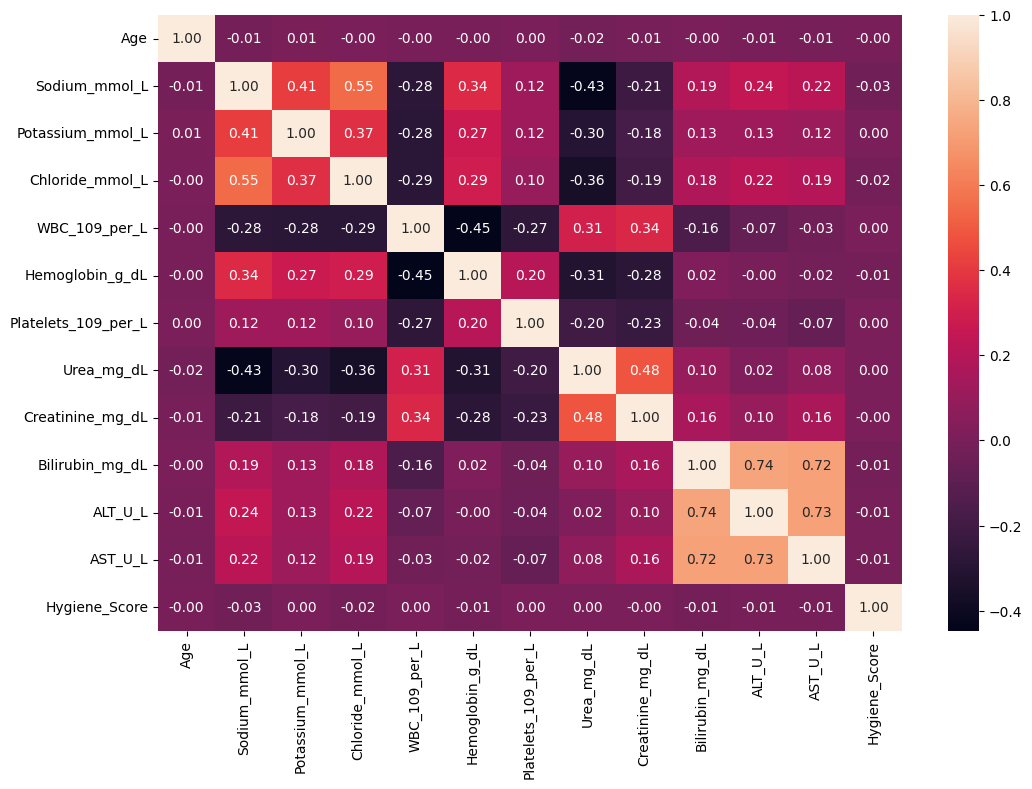

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(data.corr(numeric_only=True), annot=True, fmt=".2f")

plt.show()

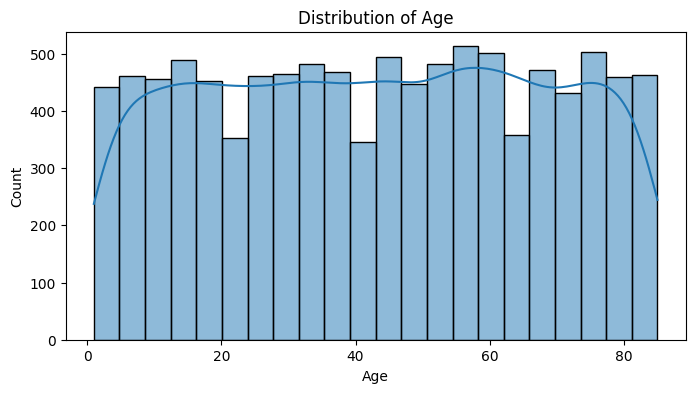

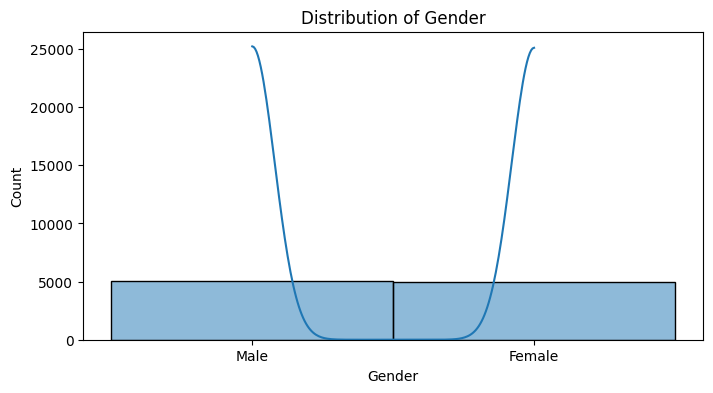

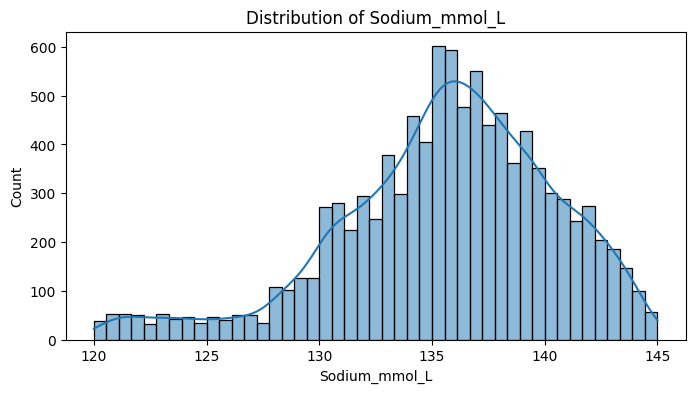

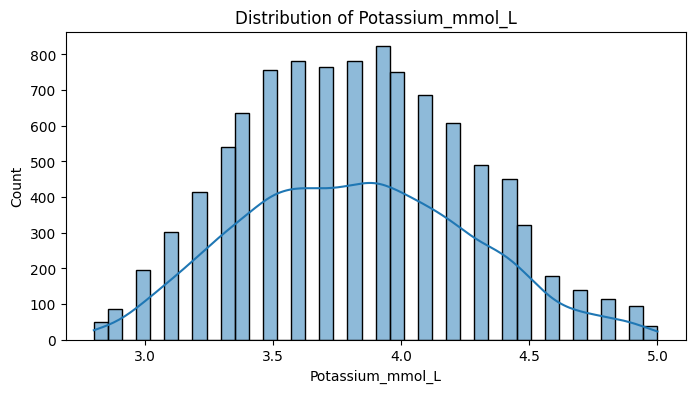

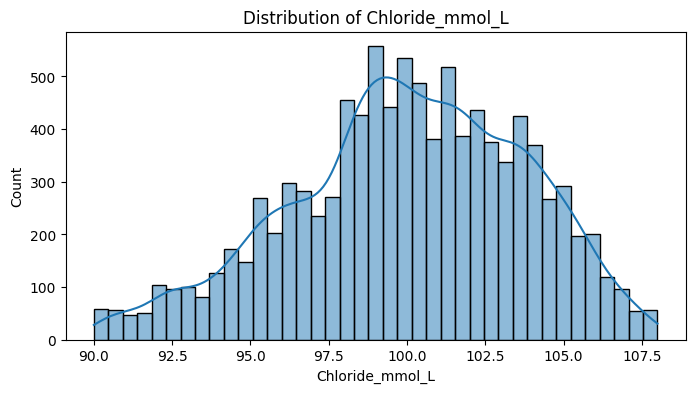

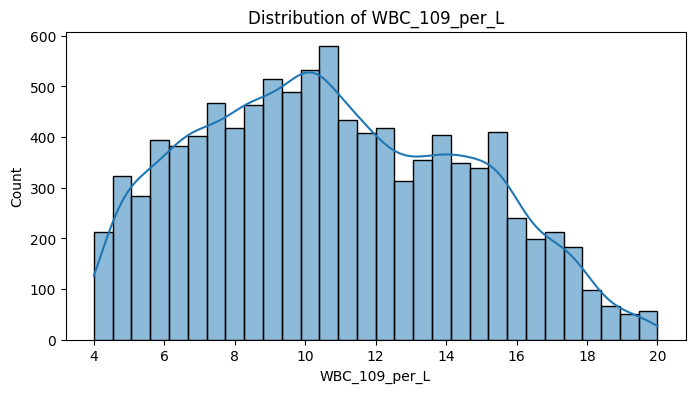

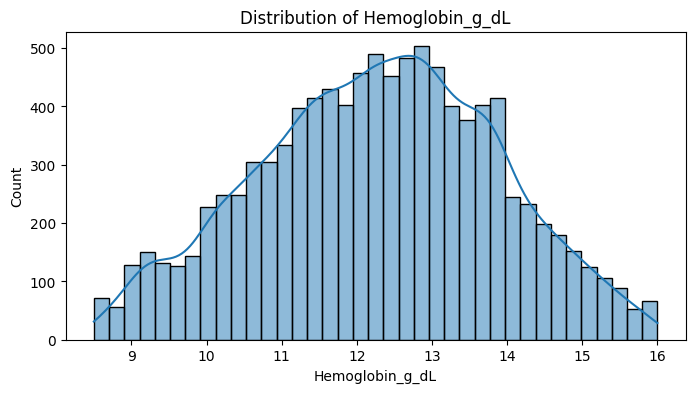

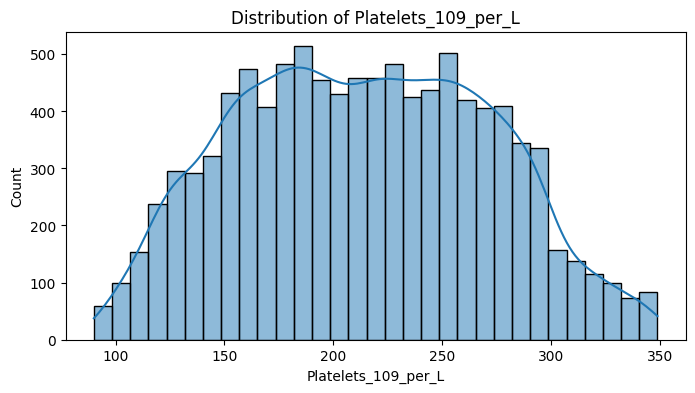

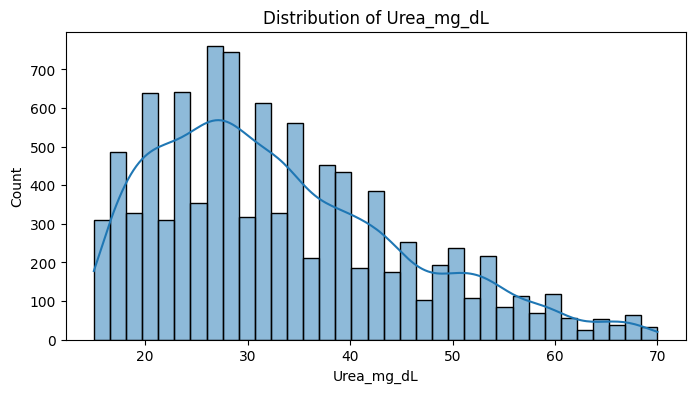

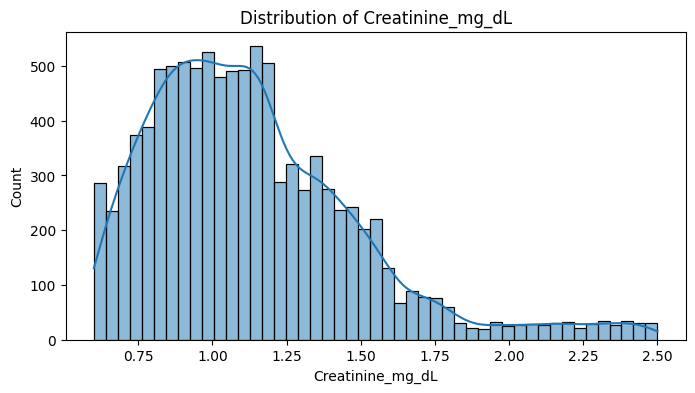

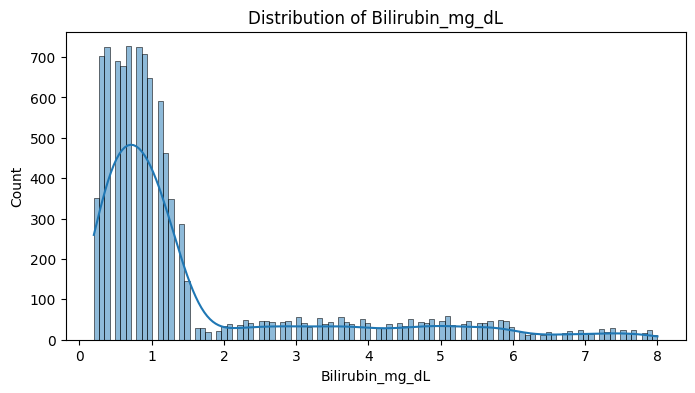

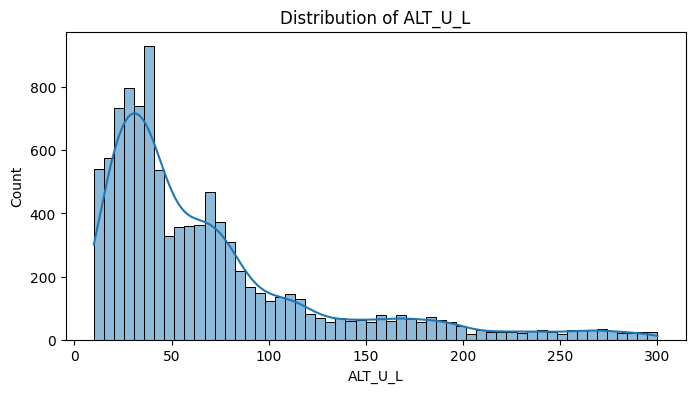

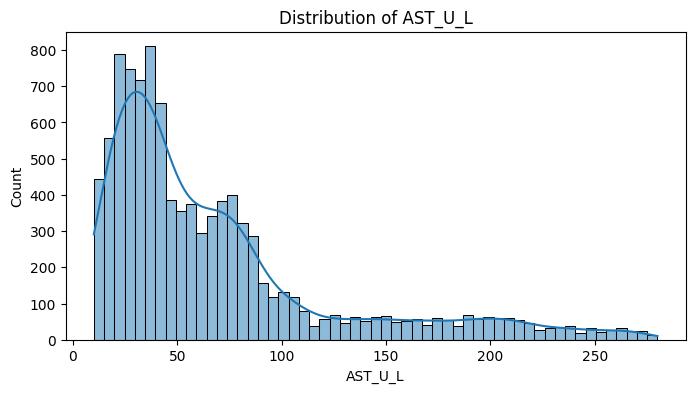

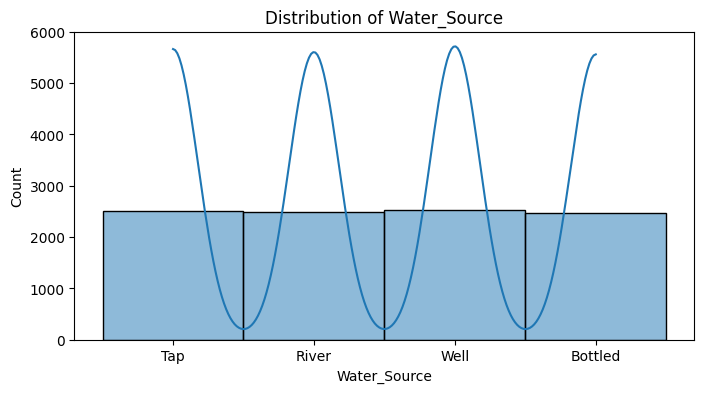

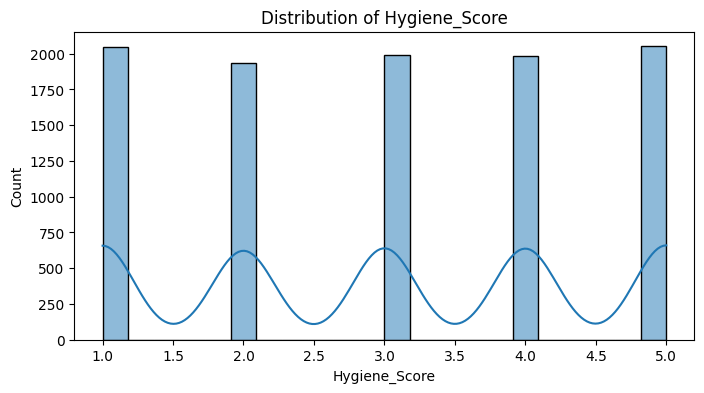

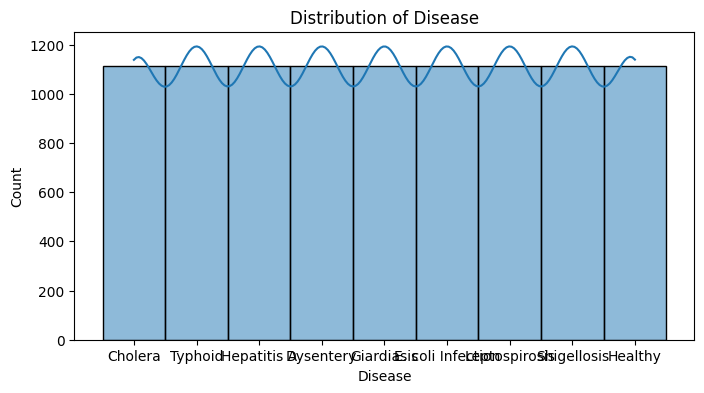

In [9]:
for col in num_col:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

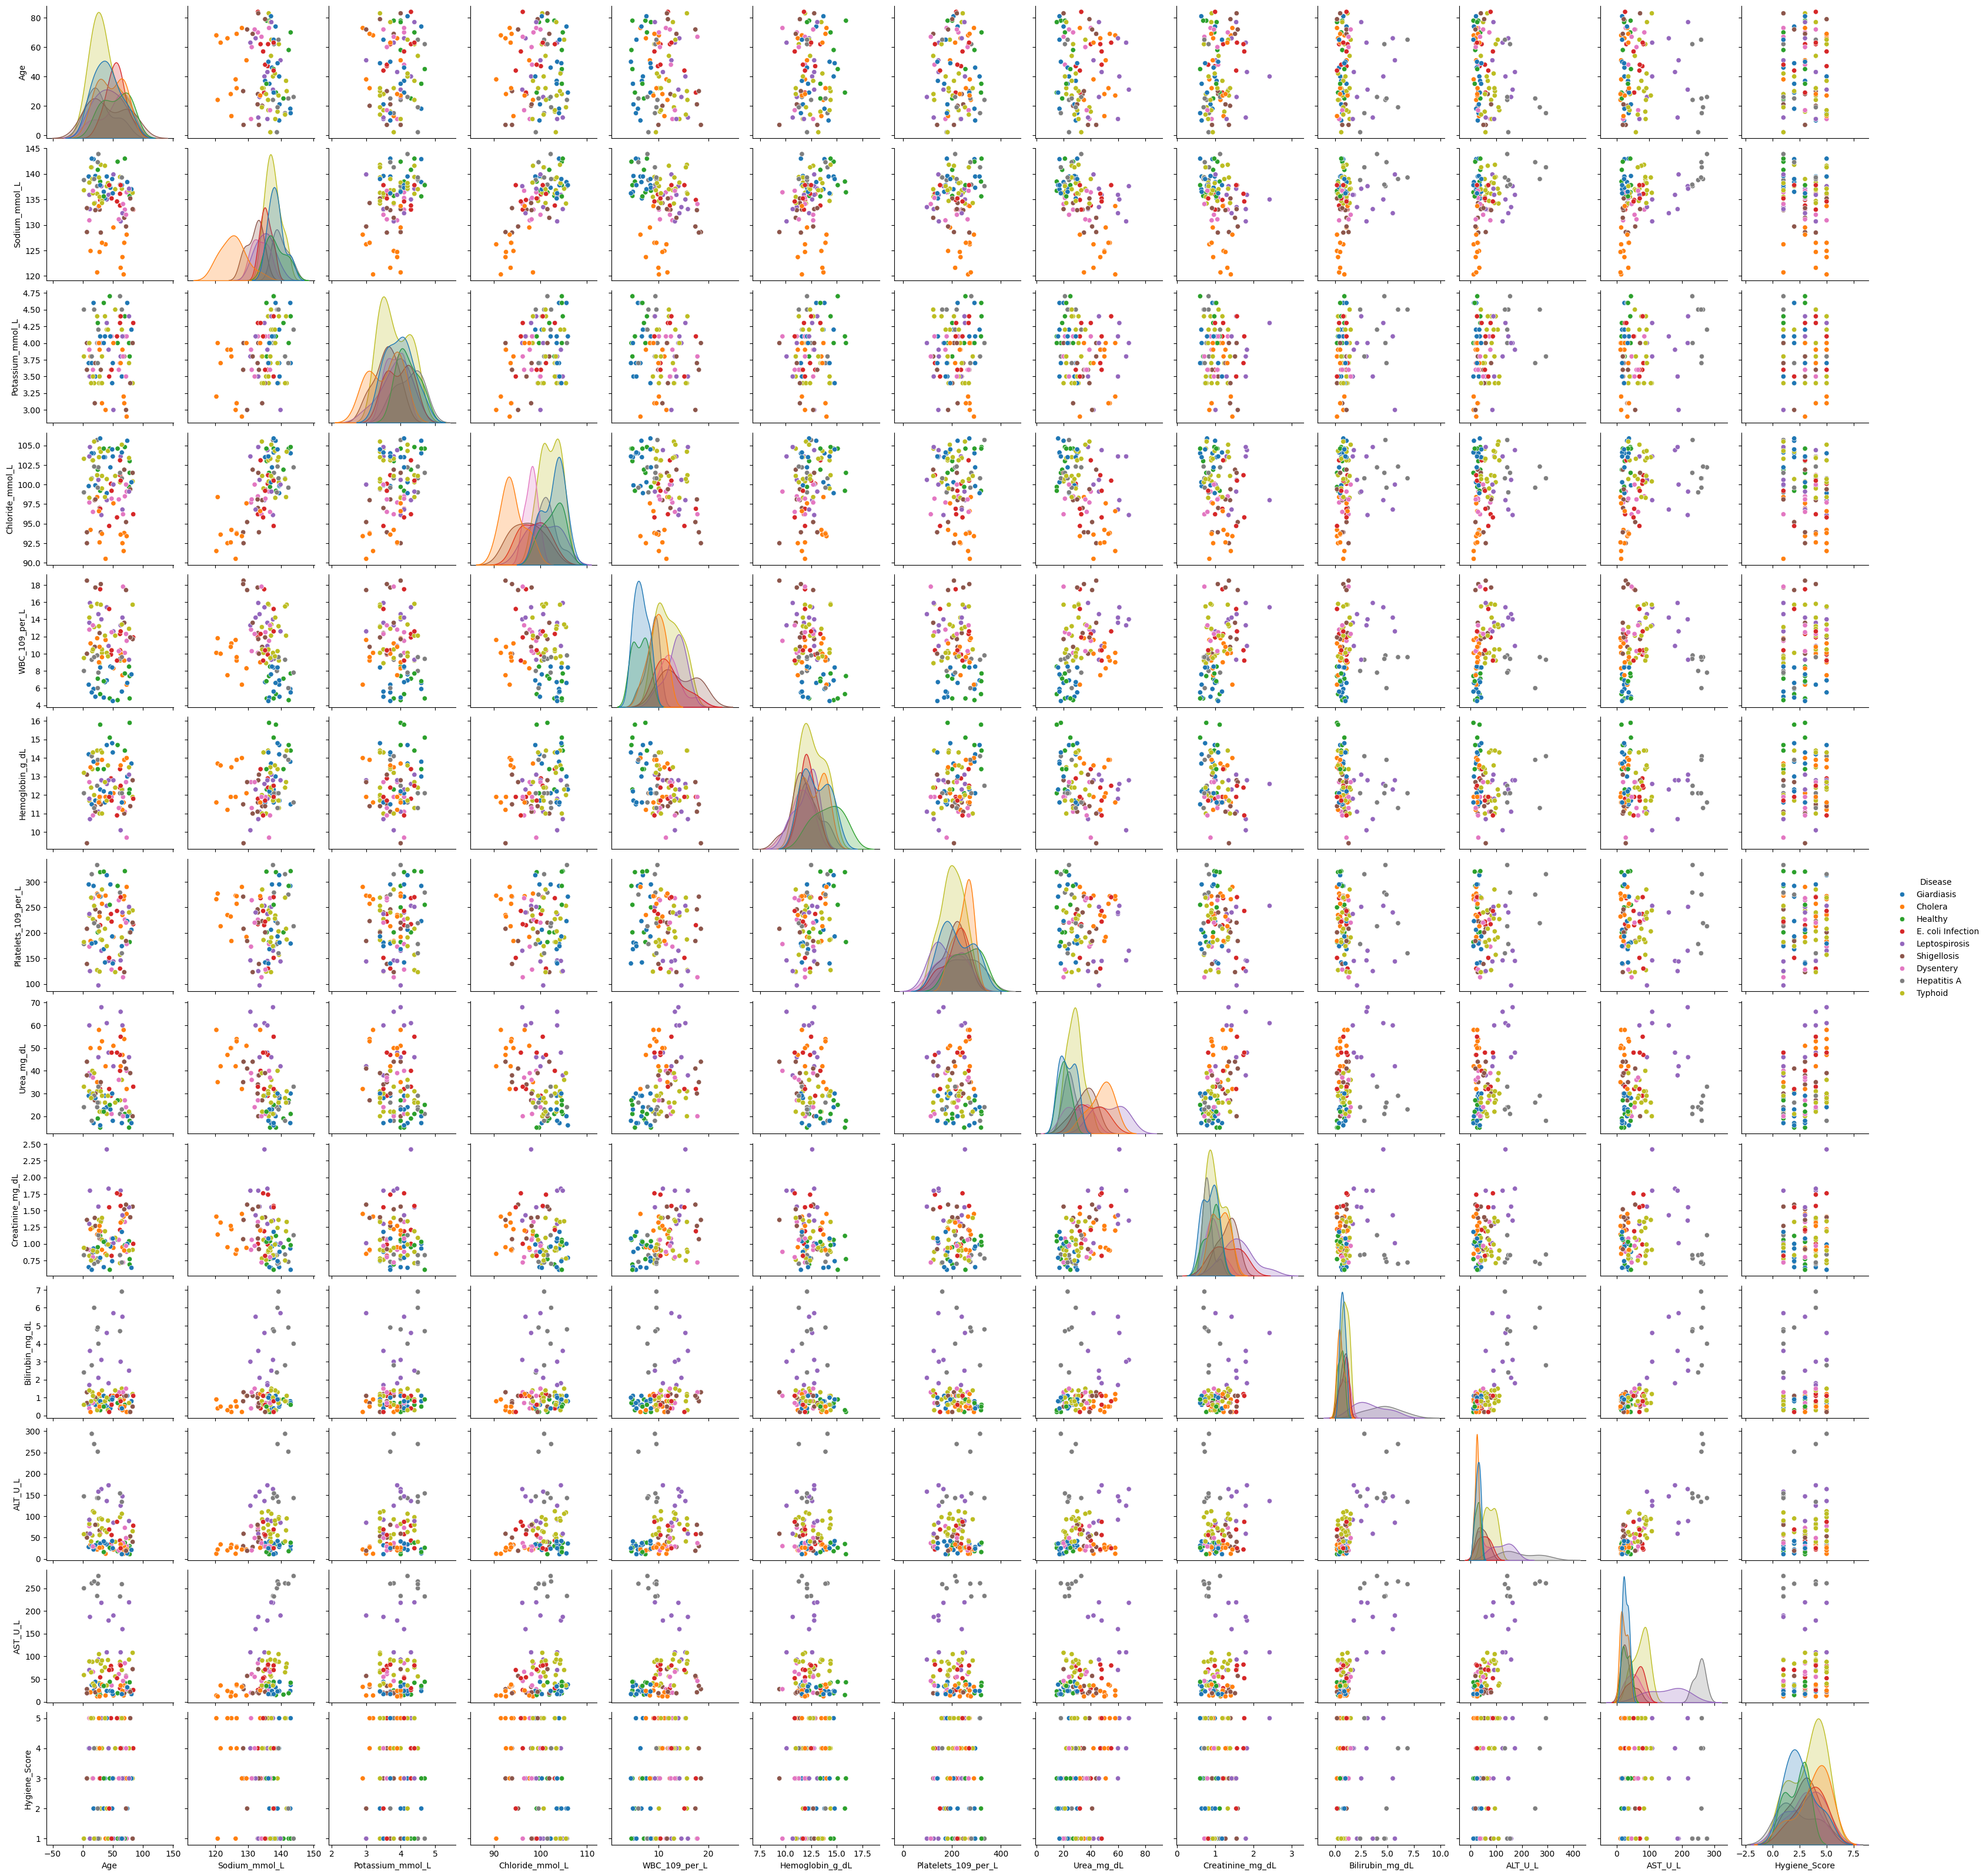

In [10]:
sns.pairplot(data.sample(100),hue='Disease')
plt.show()

In [16]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

le = LabelEncoder()
y = le.fit_transform(data['Disease'])

X = data.drop('Disease', axis=1)

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
)
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted')) 
print("Recall:", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.888
Precision: 0.8902382080093344
Recall: 0.888
F1 Score: 0.8883874945744451
Confusion Matrix:
 [[220   0   2   0   0   0   0   0   0]
 [  2 182   7   0   0   0   0  24   7]
 [  0  25 187   0   0   0   0   4   6]
 [  0   0   0 178  44   0   0   0   0]
 [  0   0   0  43 180   0   0   0   0]
 [  0   0   0   0   0 222   0   0   0]
 [  0   0   0   0   0   0 222   0   0]
 [  1  42   7   0   0   0   0 172   1]
 [  0   4   2   0   0   0   0   3 213]]


In [21]:
import joblib
joblib.dump(model, 'water_disease_model.pkl')

['water_disease_model.pkl']